In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc

large_data_dir = gf_utils.large_data_dir
matplotlib.rcParams['pdf.fonttype'] = 42

import scipy.stats as st

In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']
adata = adata[~(adata.obs['cell_type'].str.contains('non-HSPC'))]

In [3]:
### get transcript lengths
transcripts = pd.read_csv('../data/MANE_Select_transcript_lengths.tsv', sep='\t')
transcripts = transcripts.sort_values(['ensembl_transcript_id','cdna_coding_start']).copy()
# transcripts = transcripts.groupby(['ensembl_transcript_id','transcript_length','external_gene_name'])['cdna_coding_start'].min().reset_index().copy()

transcripts = transcripts.groupby(['ensembl_transcript_id','transcript_length','external_gene_name']).agg({
    'cdna_coding_start': 'min',
    'cdna_coding_end': 'max'
}).reset_index()

transcript_lengths = transcripts.set_index('external_gene_name')['transcript_length'].to_dict()
cdna_coding_starts = transcripts.set_index('external_gene_name')['cdna_coding_start'].to_dict()

def get_min_length(transcripts, gene, position):
    dist_from_start = (transcripts.loc[transcripts['external_gene_name'] == gene]['cdna_coding_start'] + position).values[0]
    dist_from_end = (transcripts.loc[transcripts['external_gene_name'] == gene]['transcript_length'] - (position + transcripts.loc[transcripts['external_gene_name'] == gene]['cdna_coding_start'])).values[0]
    return min(dist_from_start, dist_from_end)


In [4]:
### load in GoT counts per cell for comparison

CALR = pd.read_csv('../data/GSM3309842_MF05.CALR.txt', sep='\t', index_col=0)
NFE2 = pd.read_csv('../data/GSM3309843_MF05.NFE2.txt', sep='\t', index_col=0)
SF3B1 = pd.read_csv('../data/GSM3309844_MF05.SF3B1.txt', sep='\t', index_col=0)

got_data = CALR.merge(NFE2, left_index=True, right_index=True, suffixes=('_CALR', '_NFE2'), how='outer').merge(SF3B1, left_index=True, right_index=True, how='outer')
got_data.rename(columns={'num.WT.call':'num.WT.call_SF3B1', 'num.MUT.call':'num.MUT.call_SF3B1'}, inplace=True)

# Add additional rows to bring length of got_data to 8476
additional_rows_needed = 8475 - len(got_data)
if additional_rows_needed > 0:
    # Create dummy rows with NaN values
    dummy_index = [f'DUMMY_{i:04d}' for i in range(additional_rows_needed)]
    dummy_data = pd.DataFrame(index=dummy_index, columns=got_data.columns)
    got_data = pd.concat([got_data, dummy_data])

/tmp/ipykernel_381744/338691102.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  got_data = pd.concat([got_data, dummy_data])


In [5]:
MPN_props = {}
GoT_props = {}

# CALR

In [6]:
BCs = []
for i in range(8):
    manifest = pd.read_csv('../data/probe_manifests/16plex/manifest_BC00{}.tsv'.format(i + 1), sep='\t')
    if len(manifest.loc[manifest['name'] == 'CALR c.1154_1155insTTGTC']) > 0:
        BCs.append('BC00{}'.format(i + 1))
        BCs.append('BC00{}'.format(i + 9))

### then check 4-plex
manifest = pd.read_csv('../data/probe_manifests/4plex/manifest_detailed.tsv', sep='\t')
if len(manifest.loc[(manifest['name'] == 'CALR c.1154_1155insTTGTC') & (manifest['overlaps_within_set'] == 1)]) > 0:
    include_4plex = True
else:
    include_4plex = False

MPN_count = pd.DataFrame(adata[(adata.obs['sample'].str.split('_').str[0].isin(BCs)) | (adata.obs['sample'].str.contains('4-plex'))].obsm['genotypes'][['CALR c.1155_1156insTTGTC_high_confidence_counts']]).fillna(0).sum(axis=1)
MPN_count = MPN_count[~MPN_count.index.str.contains('1-plex')] ### exclude 1-plex for every variant except JAK2 (this was the only probe pair for this sample)
if not include_4plex:
    MPN_count = MPN_count[~MPN_count.index.str.contains('4-plex')]
else:
    MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
    MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])
MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]

gene = 'CALR'
distance = get_min_length(transcripts, gene, 1154)

MPN_props[gene] = {}
MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))

GoT_counts = got_data[['num.WT.call_CALR','num.MUT.call_CALR']].sum(axis=1)

GoT_props[gene] = {}
GoT_props[gene][distance] = (GoT_counts > 0).sum() / len(GoT_counts)

/tmp/ipykernel_381744/1387243592.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


# SF3B1

In [7]:
BCs = []
for i in range(8):
    manifest = pd.read_csv('../data/probe_manifests/16plex/manifest_BC00{}.tsv'.format(i + 1), sep='\t')
    if len(manifest.loc[manifest['name'] == 'SF3B1 c.2098A>G']) > 0:
        if len(manifest.loc[manifest['name'] == 'SF3B1 c.1998G>T']) > 0:
            BCs.append('BC00{}'.format(i + 1))
            BCs.append('BC00{}'.format(i + 9))

### then check 4-plex
manifest = pd.read_csv('../data/probe_manifests/4plex/manifest_detailed.tsv', sep='\t')
include_4plex = False
if len(manifest.loc[(manifest['name'] == 'SF3B1 c.2098A>G') & (manifest['overlaps_within_set'] == 1)]) > 0:
    if len(manifest.loc[(manifest['name'] == 'SF3B1 c.1998G>T') & (manifest['overlaps_within_set'] == 1)]) > 0:
        include_4plex = True


##### SF3B1 c.2098A>G
MPN_count = pd.DataFrame(adata[(adata.obs['sample'].str.split('_').str[0].isin(BCs)) | (adata.obs['sample'].str.contains('4-plex'))].obsm['genotypes'][['SF3B1 c.2098A>G_high_confidence_counts']]).fillna(0).sum(axis=1)
MPN_count = MPN_count[~MPN_count.index.str.contains('1-plex')] ### exclude 1-plex for every variant except JAK2 (this was the only probe pair for this sample)
if not include_4plex:
    MPN_count = MPN_count[~MPN_count.index.str.contains('4-plex')]
else:
    MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
    MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])
MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]

gene = 'SF3B1'
distance = get_min_length(transcripts, gene, 2098)

MPN_props[gene] = {}
MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


##### SF3B1 c.1998G>T
MPN_count = pd.DataFrame(adata[(adata.obs['sample'].str.split('_').str[0].isin(BCs)) | (adata.obs['sample'].str.contains('4-plex'))].obsm['genotypes'][['SF3B1 c.1998G>T_high_confidence_counts']]).fillna(0).sum(axis=1)
MPN_count = MPN_count[~MPN_count.index.str.contains('1-plex')] ### exclude 1-plex for every variant except JAK2 (this was the only probe pair for this sample)
if not include_4plex:
    MPN_count = MPN_count[~MPN_count.index.str.contains('4-plex')]
else:
    MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
    MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')
MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])
MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]

gene = 'SF3B1'
distance = get_min_length(transcripts, gene, 1998)

MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


/tmp/ipykernel_381744/280079995.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))
/tmp/ipykernel_381744/280079995.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


In [8]:
##### SF3B1 c.1874 (only 4-plex)

MPN_count = pd.read_csv('../output/SF3B1_1874_UMIs_per_cell.csv')
MPN_count = MPN_count.set_index('barcode').reindex(adata[(adata.obs['sample'].str.contains('4-plex'))].obs_names).fillna(0)['n_UMIs']
MPN_count.name = 'counts'
MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])

MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]

distance = get_min_length(transcripts, gene, 1874)

MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


/tmp/ipykernel_381744/3290683946.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


In [9]:
gene = 'SF3B1'

distance = get_min_length(transcripts, gene, 1984)
GoT_props[gene] = {}
GoT_props[gene][distance] = pd.Series([0.24]) ### manually from reported value for circGoT in text

# NFE2

In [10]:
### This variant was dual probe in the 16-plex panel but gapfill in the 4-plex so only consider the 4-plex

MPN_count = pd.read_csv('../output/NFE2_782_785del_UMIs_per_cell.csv')
MPN_count = MPN_count.set_index('barcode').reindex(adata[(adata.obs['sample'].str.contains('4-plex'))].obs_names).fillna(0)['n_UMIs']
MPN_count.name = 'counts'
MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])

MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]

gene = 'NFE2'
distance = get_min_length(transcripts, gene, 785)

MPN_props[gene] = {}
MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


/tmp/ipykernel_381744/3805278937.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


In [11]:
gene = 'NFE2'

distance = get_min_length(transcripts, gene, 785)

GoT_counts = got_data[['num.WT.call_NFE2','num.MUT.call_NFE2']].sum(axis=1)

GoT_props[gene] = {}
GoT_props[gene][distance] = (GoT_counts > 0).sum() / len(GoT_counts)


# JAK2

In [12]:
MPN_count = pd.DataFrame(adata.obsm['genotypes'][['JAK2 c.1849G>T_high_confidence_counts']]).fillna(0).sum(axis=1) ### include all for JAK2

MPN_count = pd.DataFrame(MPN_count, columns = ['counts'])
MPN_count.index = MPN_count.index.str.replace('4-plex','4plex')
MPN_count.index = MPN_count.index.str.replace('1-plex','1plex')

MPN_count['sample'] = MPN_count.index.str.split('-').str[-1]


gene = 'JAK2'
distance = get_min_length(transcripts, gene, 1849)

MPN_props[gene] = {}
MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))

GoT_props[gene] = {}
GoT_props[gene][distance] = pd.Series([0.073]) ### manually from reported value for circGoT in text

/tmp/ipykernel_381744/1278572770.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  MPN_props[gene][distance] = MPN_count.groupby('sample').apply(lambda x: (x['counts'] > 0).sum() / len(x))


MannwhitneyuResult(statistic=6.0, pvalue=0.9333333333333332)
1 14


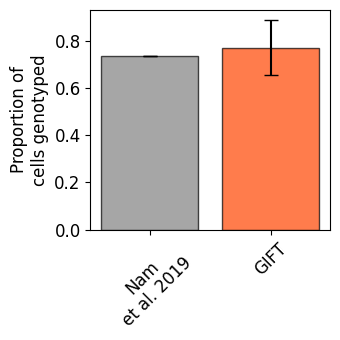

In [13]:
gene = 'CALR'
distance = list(MPN_props[gene].keys())[0]

# Create the plot
fig, ax = plt.subplots(figsize=(3.5,3.5))

# Create bar plot with error bars
x_labels = ['Nam\net al. 2019', 'GIFT']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, [GoT_props[gene][distance].mean(), MPN_props[gene][distance].mean()], yerr=[GoT_props[gene][distance].std(), MPN_props[gene][distance].std()], capsize=5, alpha=0.7, 
              color=['grey', 'orangered'],edgecolor='black')

ax.set_ylabel('Proportion of\ncells genotyped', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('../plots/CALR_MPN_capture_vs_GoT.pdf', bbox_inches='tight')

print(st.mannwhitneyu(GoT_props[gene][distance], MPN_props[gene][distance]))

print(1 if isinstance(GoT_props[gene][distance], float) else len(GoT_props[gene][distance]), len(MPN_props[gene][distance]))

MannwhitneyuResult(statistic=3.0, pvalue=0.5)
1 3


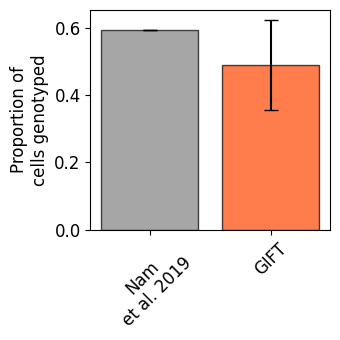

In [14]:
gene = 'NFE2'
distance = list(MPN_props[gene].keys())[0]

# Create the plot
fig, ax = plt.subplots(figsize=(3.5,3.5))

# Create bar plot with error bars
x_labels = ['Nam\net al. 2019', 'GIFT']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, [GoT_props[gene][distance].mean(), MPN_props[gene][distance].mean()], yerr=[GoT_props[gene][distance].std(), MPN_props[gene][distance].std()], capsize=5, alpha=0.7, 
              color=['grey', 'orangered'],edgecolor='black')

ax.set_ylabel('Proportion of\ncells genotyped', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('../plots/NFE2_MPN_capture_vs_GoT.pdf', bbox_inches='tight')

print(st.mannwhitneyu(GoT_props[gene][distance], MPN_props[gene][distance]))
print(1 if isinstance(GoT_props[gene][distance], float) else len(GoT_props[gene][distance]), len(MPN_props[gene][distance]))

MannwhitneyuResult(statistic=3.0, pvalue=0.21621621621621623)
1 36


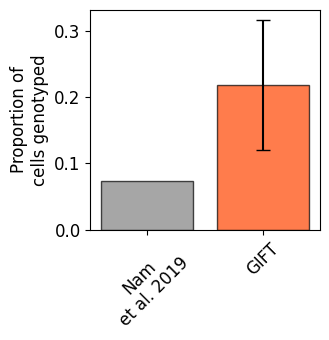

In [15]:
gene = 'JAK2'
distance = list(MPN_props[gene].keys())[0]

# Create the plot
fig, ax = plt.subplots(figsize=(3.5,3.5))

# Create bar plot with error bars
x_labels = ['Nam\net al. 2019', 'GIFT']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, [GoT_props[gene][distance].mean(), MPN_props[gene][distance].mean()], yerr=[GoT_props[gene][distance].std(), MPN_props[gene][distance].std()], capsize=5, alpha=0.7, 
              color=['grey','orangered'],edgecolor='black')

ax.set_ylabel('Proportion of\ncells genotyped', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('../plots/JAK2_MPN_capture_vs_GoT.pdf', bbox_inches='tight')

print(st.mannwhitneyu(GoT_props[gene][distance], MPN_props[gene][distance]))

print(1 if isinstance(GoT_props[gene][distance], float) else len(GoT_props[gene][distance]), len(MPN_props[gene][distance]))

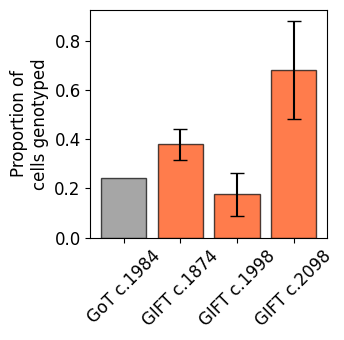

In [16]:
gene = 'SF3B1'

# Create the plot
fig, ax = plt.subplots(figsize=(3.5,3.5))

distances = sorted(list(MPN_props['SF3B1'].keys()))
# Create bar plot with error bars
x_labels = ['GoT c.1984', 'GIFT c.1874', 'GIFT c.1998','GIFT c.2098']
x_pos = np.arange(len(x_labels))

bars = ax.bar(x_pos, [GoT_props[gene][list(GoT_props['SF3B1'].keys())[0]].mean(), MPN_props[gene][distances[0]].mean(), MPN_props[gene][distances[1]].mean(), MPN_props[gene][distances[2]].mean()], yerr=[GoT_props[gene][list(GoT_props['SF3B1'].keys())[0]].std(), MPN_props[gene][distances[0]].std(), MPN_props[gene][distances[1]].std(), MPN_props[gene][distances[2]].std()], capsize=5, alpha=0.7, 
              color=['grey','orangered','orangered','orangered'],edgecolor='black')

ax.set_ylabel('Proportion of\ncells genotyped', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='center', size=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('../plots/SF3B1_MPN_capture_vs_GoT.pdf', bbox_inches='tight')
